In [28]:
import sys
from pathlib import Path

root_path = Path.cwd().parent.parent

sys.path.append(str(root_path))
params_path = root_path / "params/"

import json
import logging

import matplotlib.pyplot as plt
import numpy as np

from domain.distributions import TiltedWashboardDistribution, WrappedGaussian
from plotting.plot_style import plot_style
from src.mle_multiple_inits import mle_fit_multiple_inits
from utils.sampling.sampling_tilted_washboard import (
    sample_tilted_washboard_distribution,
)
from utils.seed import set_seed

In [29]:
# Force verbose logging in notebook

logging.basicConfig(level=logging.INFO, force=True)

In [30]:
with open(params_path / "mle_constraints.json", "r") as f:
    constraints = json.load(f)

constraints_tilted_washboard = {
    k: tuple(v) for k, v in constraints["constraints_tilted_washboard"].items()
}
constraints_wrapped_gaussian = {
    k: tuple(v) for k, v in constraints["constraints_wrapped_gaussian"].items()
}

In [31]:
set_seed(123)

# Generate synthetic data with rejection sampling

In [32]:
true_a = 420
true_b = 440
x_min = np.arcsin(true_a / true_b)
x_grid = np.linspace(x_min - 0.4, x_min + 0.4, 1000)

dist = TiltedWashboardDistribution(a=true_a, b=true_b)
data = sample_tilted_washboard_distribution(dist, n=1000, x_grid=x_grid)

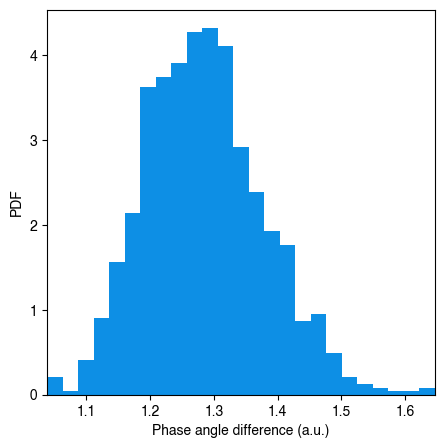

In [33]:
with plot_style():

    fig, ax = plt.subplots(1, 1, figsize=(5, 5))
    colors = plt.rcParams["axes.prop_cycle"].by_key()["color"]

    ax.hist(data, bins=25, density=True)

    ax.set_xlim(data.min(), data.max())

    ax.set_xlabel("Phase angle difference (a.u.)")
    ax.set_ylabel("PDF")

    plt.show()

# MLE fit

In [34]:
param_inits = [
    {"a": 400, "b": 420},
]  # to run with multiple inits pass [{"a": <val>, "b": <val>}, {"a": <val>, "b": <val>}, ...]

result = mle_fit_multiple_inits(
    data=data,
    distribution="tilted_washboard",
    init_list=param_inits,
    constraints=constraints_tilted_washboard,
    max_iter=500,
    std_threshold=25,
    x_grid=x_grid,  # Grid for normalization of pdf (taken from sampling)
    verbose=True,
)

INFO:root:Running initialization: 1/1: {'a': 400, 'b': 420}
INFO:root:Starting MLE optimization for tilted_washboard distribution
INFO:root:Initial parameters: {'a': 400, 'b': 420}
INFO:root:neg_log_likelihood=957.215827, delta_x=2.00e+01, delta_f=1.92e+03, params=[420. 420.]
INFO:root:neg_log_likelihood=663.933600, delta_x=2.10e+01, delta_f=2.93e+02, params=[400. 441.]
INFO:root:neg_log_likelihood=4552.165785, delta_x=2.00e+01, delta_f=3.89e+03, params=[380. 441.]
INFO:root:neg_log_likelihood=-907.124719, delta_x=3.00e+01, delta_f=5.46e+03, params=[410.   425.25]
INFO:root:neg_log_likelihood=2296.680163, delta_x=2.10e+01, delta_f=3.20e+03, params=[410.   404.25]
INFO:root:neg_log_likelihood=-572.332047, delta_x=2.76e+01, delta_f=2.87e+03, params=[402.5    431.8125]
INFO:root:neg_log_likelihood=-138.182782, delta_x=1.84e+01, delta_f=4.34e+02, params=[407.5    413.4375]
INFO:root:neg_log_likelihood=-890.720233, delta_x=1.38e+01, delta_f=7.53e+02, params=[403.75    427.21875]
INFO:root:n

Optimization terminated successfully.
         Current function value: -971.918007
         Iterations: 86
         Function evaluations: 187


In [35]:
a_fit = result[0]["a"][0]
b_fit = result[0]["b"][0]
fitted_distribution = TiltedWashboardDistribution(a=a_fit, b=b_fit)

In [36]:
param_inits = [
    {"mu": 1.0, "sigma": 0.1},
]

result_wg = mle_fit_multiple_inits(
    data=data,
    distribution="wrapped_gaussian",
    init_list=param_inits,
    constraints=constraints_wrapped_gaussian,
    max_iter=500,
    std_threshold=25,
    x_grid=x_grid,  # Grid for normalization of pdf (taken from sampling)
    verbose=True,
)

INFO:root:Running initialization: 1/1: {'mu': 1.0, 'sigma': 0.1}
INFO:root:Starting MLE optimization for wrapped_gaussian distribution
INFO:root:Initial parameters: {'mu': 1.0, 'sigma': 0.1}
INFO:root:neg_log_likelihood=1814.539788, delta_x=5.00e-02, delta_f=1.30e+03, params=[1.05 0.1 ]
INFO:root:neg_log_likelihood=2746.545663, delta_x=5.00e-02, delta_f=9.32e+02, params=[1.    0.105]
INFO:root:neg_log_likelihood=1565.992900, delta_x=5.00e-02, delta_f=1.18e+03, params=[1.05  0.105]
INFO:root:neg_log_likelihood=974.153074, delta_x=2.50e-02, delta_f=5.92e+02, params=[1.075  0.1075]
INFO:root:neg_log_likelihood=273.024367, delta_x=5.00e-02, delta_f=7.01e+02, params=[1.125  0.1025]
INFO:root:neg_log_likelihood=-485.543989, delta_x=6.25e-02, delta_f=7.59e+02, params=[1.1875  0.10125]
INFO:root:neg_log_likelihood=-712.374844, delta_x=2.50e-02, delta_f=2.27e+02, params=[1.2125  0.10875]
INFO:root:neg_log_likelihood=-921.842994, delta_x=8.13e-02, delta_f=2.09e+02, params=[1.29375  0.113125]
INF

Optimization terminated successfully.
         Current function value: -959.520772
         Iterations: 60
         Function evaluations: 116


In [37]:
mu_fit = result_wg[0]["mu"][0]
sigma_fit = result_wg[0]["sigma"][0]
fitted_wrapped_gaussian = WrappedGaussian(mu=mu_fit, sigma=sigma_fit)

In [38]:
x_range = np.linspace(x_min - 0.4, x_min + 0.4, 100)
pdf_tw = fitted_distribution.pdf(x=x_range, x_grid=x_grid)
pdf_wg = fitted_wrapped_gaussian.pdf(x=x_range)

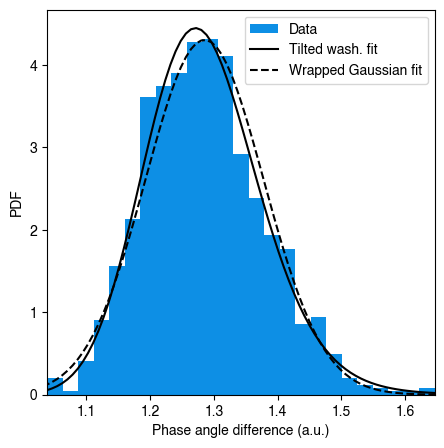

In [39]:
with plot_style():

    fig, ax = plt.subplots(1, 1, figsize=(5, 5))
    colors = plt.rcParams["axes.prop_cycle"].by_key()["color"]

    ax.hist(data, bins=25, density=True, label="Data")
    ax.plot(x_range, pdf_tw, color="black", lw=1.5, label="Tilted wash. fit")
    ax.plot(x_range, pdf_wg, color="black", ls="dashed", lw=1.5, label="Wrapped Gaussian fit")

    ax.set_xlim(data.min(), data.max())

    ax.set_xlabel("Phase angle difference (a.u.)")
    ax.set_ylabel("PDF")

    ax.legend(loc="best")

    plt.show()